In [6]:
import numpy as np
import os
import matplotlib.pyplot as plt
import copy

from util.DataGen import nai_pulse, plastic_pulse, continuous_time_trace
from util.Processing import trace_to_counts, threshold_nnlsr_deconvolve, iterated_subtraction
from util.metrics import volts_counted_hist, volts_counted_pct, events_counted

In [7]:
sensor_type = 'NaI'
assert sensor_type in ['NaI', 'plastic']

N_TRACES_PER_COUNTRATE=1

# Trace Parameters
keV_per_area = .147
mV_per_ADC = 1000/4096
baseline = 0 # mV
basenoise= 0 # mV
bits = 10
clip = 1000 # mV
fs = 40E6 # new HERA sampling rate
total_time = 5E-5
# for Lognormal traces
fwhm = 50 #50.0 #fwhm of the total TGF count distribution in units microseconds
mean = .007, #.7 #mean of the TGF trace distribution
std = 0 #.5 #determines the amount of assymetry in the TGF trace distribution

if sensor_type == 'plastic':
    _, kernel = plastic_pulse(1)
    spectrum = np.loadtxt('../original/LgPl_Response', usecols=(1), dtype=float)
    bins = 1E3 * np.loadtxt('../original/LgPl_Response', usecols=(0), dtype=float)  # in kev
else:
    _, kernel = nai_pulse(1, 101)
    spectrum = np.loadtxt('../original/NaI_Response', usecols=(1), dtype=float)
    bins = 1E3 * np.loadtxt('../original/NaI_Response', usecols=(0), dtype=float)  # in kev
    
common_trace_kwargs = {
    'count_rate': 1E6,
    'trace_type': 'constant',
    'keV_per_area' : keV_per_area,
    'mV_per_ADC' : mV_per_ADC,
    'baseline' : baseline, # mV
    'basenoise': basenoise, # mV
    'bits' : bits,
    'clip_magnitude' : clip, # mV
    'fs' : fs, # new HERA sampling rate
    'total_time' : total_time,
    'spectrum_hist': spectrum,
    'detector_response_kernel': kernel,
    'spectrum_bin_energies':bins,
    # for Lognormal traces
    'lognormal_fwhm' : fwhm, #50.0 #fwhm of the total TGF count distribution in units microseconds
    'lognormal_mean' : mean, #.7 #mean of the TGF trace distribution
    'lognormal_std' : std, #.5 #determines the amount of assymetry in the TGF trace distribution
    'return_object':True
}


In [8]:
tracedata = continuous_time_trace(**common_trace_kwargs)
microseconds = 1E6 * tracedata.sample_t
print(type(tracedata))

<class 'util.DataGen.TraceData'>


In [9]:
tnnlsr_convsum_kwargs = {
    'threshold' : 1,
    'kernel': kernel,
    'nsum': 3,
    'sigma': 3,
    'distance': 2,
    'return_dict':True,
    'debug': True,
}

d = threshold_nnlsr_deconvolve(y=tracedata.trace, **tnnlsr_convsum_kwargs)
volts = d['volts']
indeces = d['indeces']

(-1.0, 205.17578125000003)

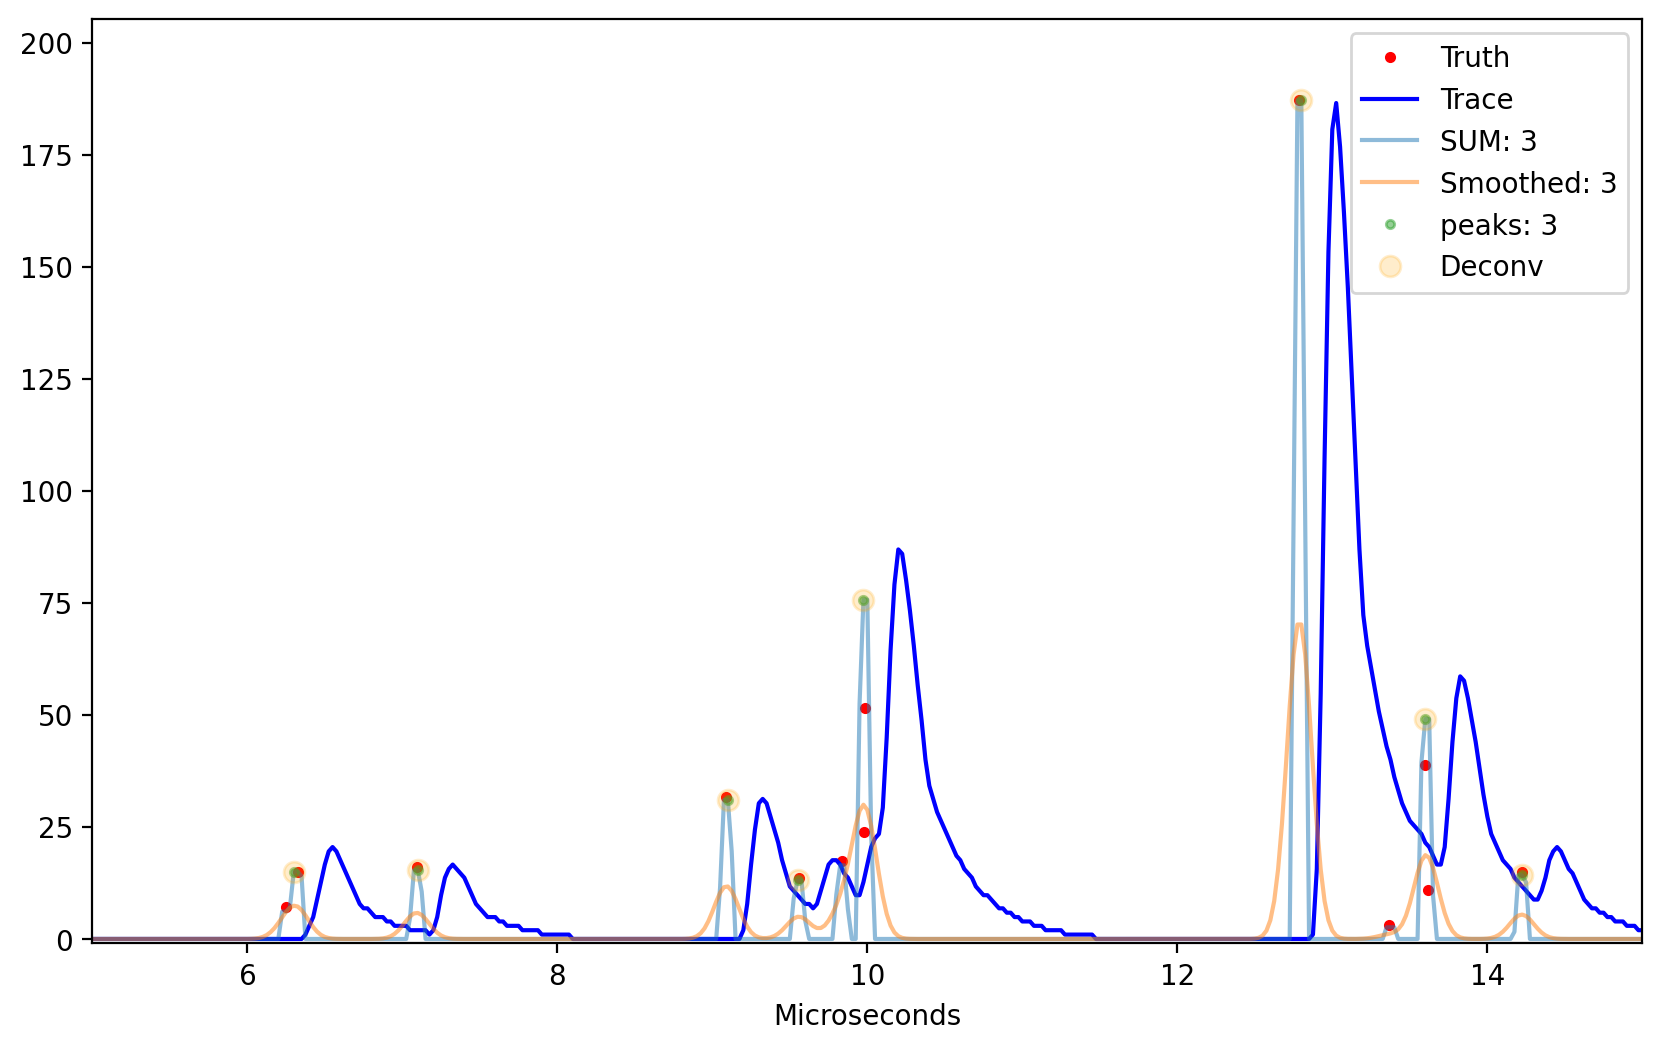

In [12]:
plt.figure(figsize=(10,6), dpi=200)
plt.plot(1E6 * tracedata.event_times, tracedata.event_voltages, label='Truth',color='red', linestyle='', marker='.')
plt.plot(microseconds, tracedata.trace, label='Trace', color='blue')


if 'convsum' in d:
    plt.plot(microseconds, d['convsum'], label='SUM: {}'.format(tnnlsr_convsum_kwargs['nsum']), alpha=.5)
if 'smoothed' in d:
    plt.plot(microseconds, d['smoothed'], label='Smoothed: {}'.format(tnnlsr_convsum_kwargs['nsum']), alpha=.5)
if 'convsum_peaks' in d:
    peaks = d['convsum_peaks']
    plt.plot(microseconds[peaks], d['convsum'][peaks], label='peaks: {}'.format(tnnlsr_convsum_kwargs['nsum']),
             alpha=.5, linestyle='', marker='.')
    
plt.plot(microseconds[indeces], volts, label='Deconv',color='orange', linestyle='', marker='.', markersize=15, alpha=.2)

xlim = (5,15)
plt.legend()
plt.xlabel('Microseconds')
plt.xlim(xlim)
plt.ylim(-1, np.max(1.1 * tracedata.trace[np.logical_and(xlim[0] <= microseconds, microseconds <=  xlim[1])]))